# KNN + HAC

--- Sentence Classification Report (Participants) ---
              precision    recall  f1-score   support

        No P       0.85      0.89      0.87      1487
       Has P       0.62      0.53      0.57       513

    accuracy                           0.80      2000
   macro avg       0.73      0.71      0.72      2000
weighted avg       0.79      0.80      0.79      2000



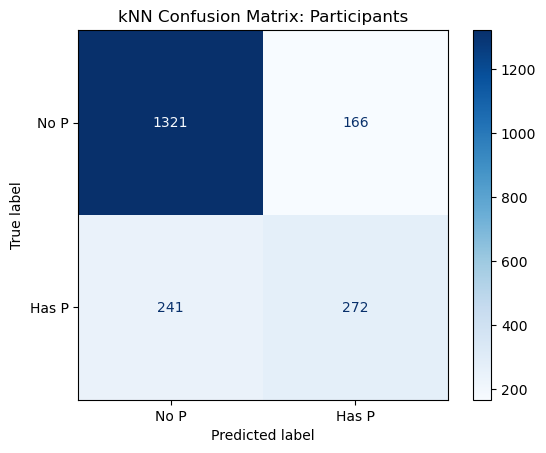

--- Sentence Classification Report (Outcomes) ---
              precision    recall  f1-score   support

        No O       0.70      0.64      0.67      1146
       Has O       0.57      0.64      0.60       854

    accuracy                           0.64      2000
   macro avg       0.64      0.64      0.64      2000
weighted avg       0.65      0.64      0.64      2000



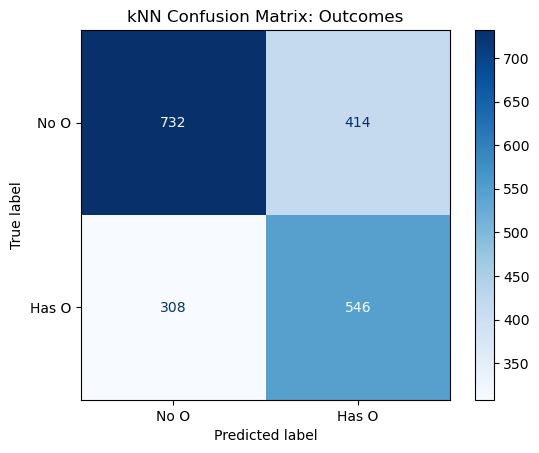

--- Sentence Classification Report (Interventions) ---
              precision    recall  f1-score   support

        No I       0.73      0.66      0.69      1099
       Has I       0.63      0.70      0.66       901

    accuracy                           0.68      2000
   macro avg       0.68      0.68      0.68      2000
weighted avg       0.68      0.68      0.68      2000



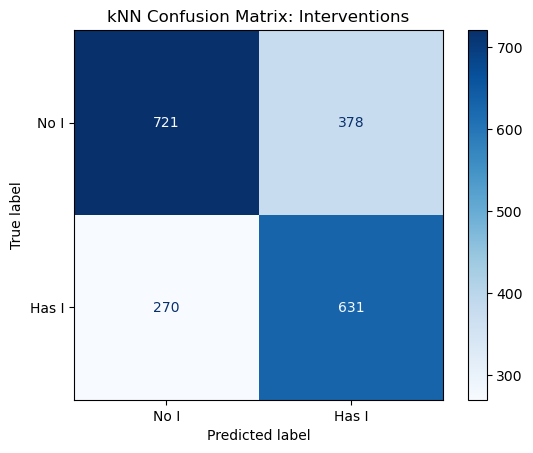

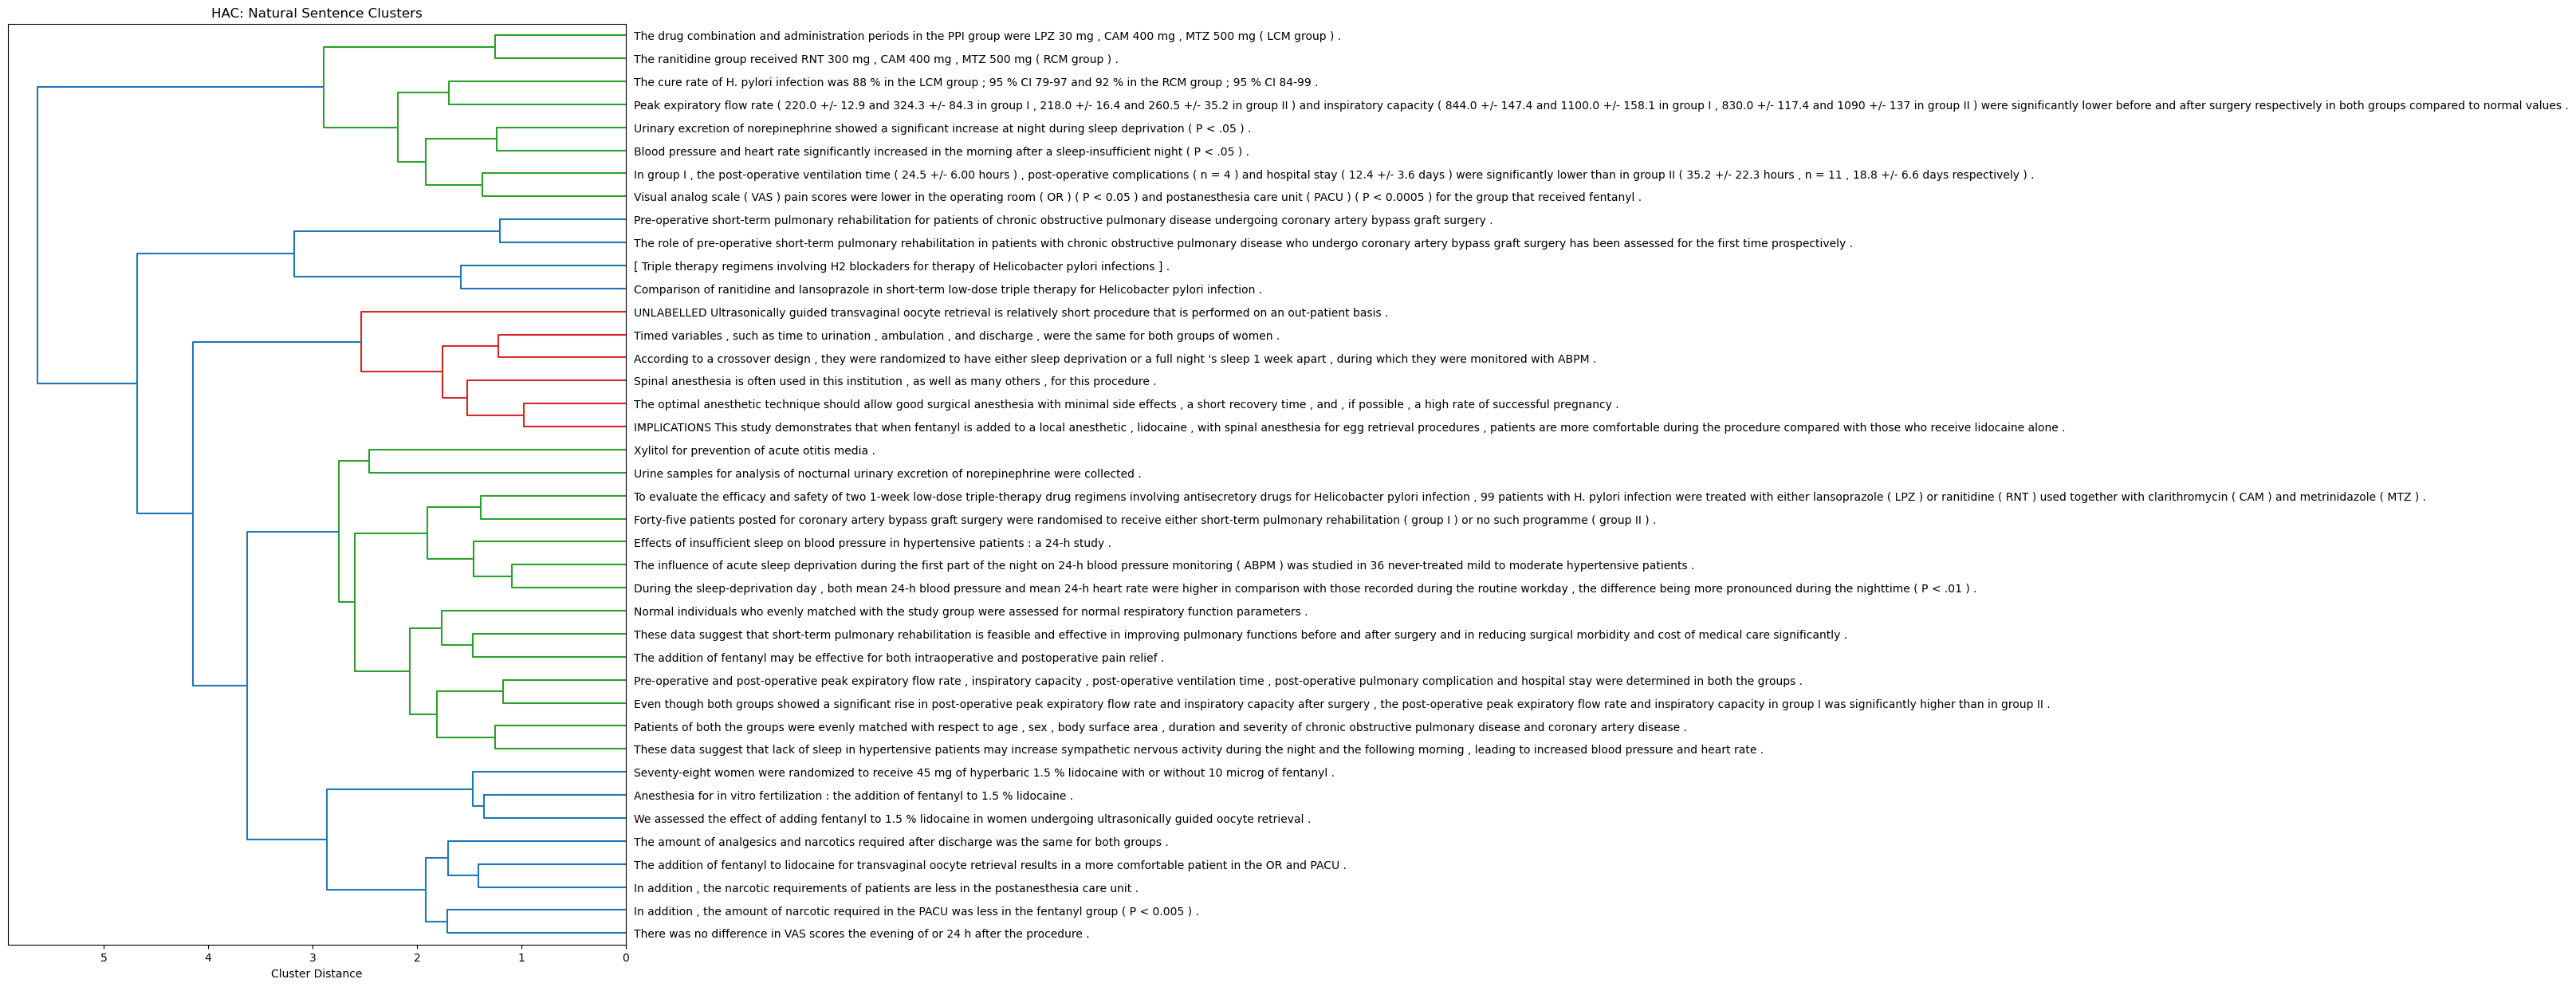

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.cluster.hierarchy import set_link_color_palette

data = np.load("./data/ebm_nlp_2_00/processed/ebm_sentence_vectors.npz", allow_pickle=True)

X_train = data['X_train']
X_test = data['X_test']

train_texts = data['texts_train']

# shows the different clusters depending on the label
def plot_knn(y_selection):
    names = {'p': 'Participants', 'i': 'Interventions', 'o': 'Outcomes'}
    full_name = names.get(y_selection, "Unknown")
    
    y_train = data[f"y_{y_selection}_train"]
    y_test = data[f"y_{y_selection}_test"]
    
    knn = KNeighborsClassifier(n_neighbors=5)
    train_limit = min(30000, len(X_train))
    knn.fit(X_train[:train_limit], y_train[:train_limit])
    
    test_limit = min(2000, len(X_test))
    knn_preds = knn.predict(X_test[:test_limit])
    
    target_names = [f"No {y_selection.upper()}", f"Has {y_selection.upper()}"]
    
    print(f"--- Sentence Classification Report ({full_name}) ---")
    print(classification_report(y_test[:test_limit], knn_preds, target_names=target_names))
    
    cm = confusion_matrix(y_test[:test_limit], knn_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"kNN Confusion Matrix: {full_name}")
    plt.show()

# lets keep it interpretable!
def plot_hac(sample_size=40):
    set_link_color_palette(['#1f77b4', '#2ca02c', '#d62728']) 
    
    X_hac = X_train[:sample_size]
    labels_hac = train_texts[:sample_size]
    linked_sentences = linkage(X_hac, 'ward')
    
    plt.figure(figsize=(10, 15))
    dendrogram(
        linked_sentences,
        orientation='left',       
        labels=labels_hac,      
        distance_sort='descending',
        show_leaf_counts=True,
        leaf_font_size=10,
        color_threshold=3.5
    )
    
    plt.title("HAC: Natural Sentence Clusters")
    plt.xlabel("Cluster Distance")
    plt.show()
    
    set_link_color_palette(None)

plot_knn('p')
plot_knn('o')
plot_knn('i')
plot_hac()